# Histogram Comparison of Two Images

This notebook covers standard image histogram comparison.
1. **Import Required Libraries**: OpenCV, Matplotlib, NumPy.
2. **Load and Display Images**: Reads two sample images and visualizes them side-by-side. 
3. **Calculate Histograms**: Computes the color or grayscale histograms.
4. **Plot and Compare Histograms**: Visual comparison of the two distributions.
5. **Quantitative Comparison**: Computes statistical similarities such as Correlation, Chi-Square, and Bhattacharyya distance.

<>:8: SyntaxWarning: invalid escape sequence '\S'
<>:9: SyntaxWarning: invalid escape sequence '\S'
<>:8: SyntaxWarning: invalid escape sequence '\S'
<>:9: SyntaxWarning: invalid escape sequence '\S'
C:\Users\User\AppData\Local\Temp\ipykernel_27416\107262272.py:8: SyntaxWarning: invalid escape sequence '\S'
  img1_path = 'D:\Study materials\Year 2\SEGP\OOD Verification\Jiawei\SUltra s23\WhatsApp Image 2026-03-15 at 14.03.02.jpeg'
C:\Users\User\AppData\Local\Temp\ipykernel_27416\107262272.py:9: SyntaxWarning: invalid escape sequence '\S'
  img2_path = 'D:\Study materials\Year 2\SEGP\OOD Verification\Jiawei\IP\WhatsApp Image 2026-03-15 at 14.03.48.jpeg'


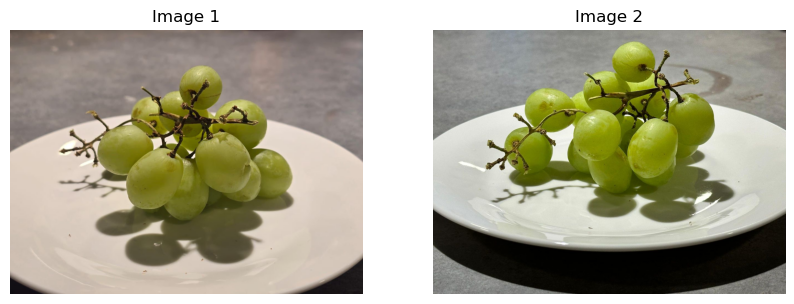

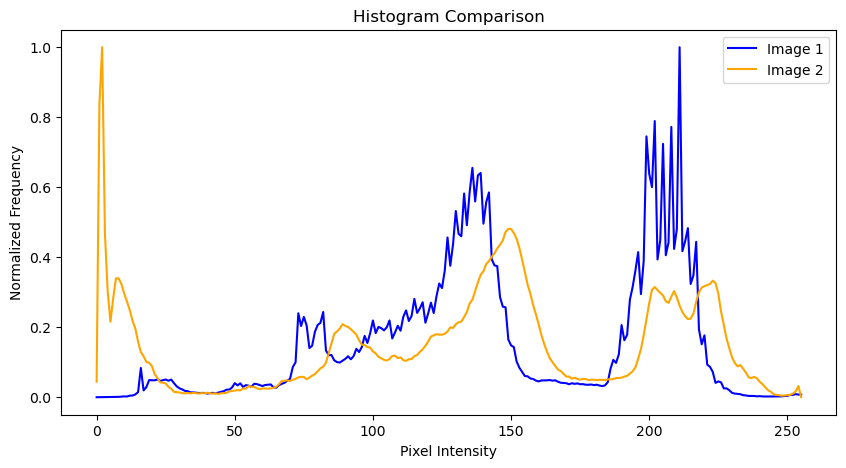

Histogram Comparison Metrics:
Correlation (closer to 1 is better): 0.3969
Chi-Square (closer to 0 is better): 16249.3452
Bhattacharyya Distance (closer to 0 is better): nan


In [2]:
# 1. Import Required Libraries
import cv2
import numpy as np
import matplotlib.pyplot as plt

# 2. Load and Display Images
# Please replace 'image1.jpg' and 'image2.jpg' with your actual image paths from your dataset directory
img1_path = 'D:\Study materials\Year 2\SEGP\OOD Verification\Jiawei\SUltra s23\WhatsApp Image 2026-03-15 at 14.03.02.jpeg'
img2_path = 'D:\Study materials\Year 2\SEGP\OOD Verification\Jiawei\IP\WhatsApp Image 2026-03-15 at 14.03.48.jpeg'

# Read images
img1 = cv2.imread(img1_path)
img2 = cv2.imread(img2_path)

if img1 is None or img2 is None:
    print(f"Error loading images. Please check the paths: {img1_path} and {img2_path}.")
else:
    # Convert BGR (OpenCV default) to RGB for Matplotlib
    img1_rgb = cv2.cvtColor(img1, cv2.COLOR_BGR2RGB)
    img2_rgb = cv2.cvtColor(img2, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 1)
    plt.title("Image 1")
    plt.imshow(img1_rgb)
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.title("Image 2")
    plt.imshow(img2_rgb)
    plt.axis("off")
    plt.show()

    # 3. Calculate Histograms (using Grayscale for simplicity in comparison)
    img1_gray = cv2.cvtColor(img1, cv2.COLOR_BGR2GRAY)
    img2_gray = cv2.cvtColor(img2, cv2.COLOR_BGR2GRAY)

    hist1 = cv2.calcHist([img1_gray], [0], None, [256], [0, 256])
    hist2 = cv2.calcHist([img2_gray], [0], None, [256], [0, 256])

    # Normalize histograms to handle images of different sizes
    cv2.normalize(hist1, hist1, alpha=0, beta=1, norm_type=cv2.NORM_MINMAX)
    cv2.normalize(hist2, hist2, alpha=0, beta=1, norm_type=cv2.NORM_MINMAX)

    # 4. Plot and Compare Histograms
    plt.figure(figsize=(10, 5))
    plt.title("Histogram Comparison")
    plt.plot(hist1, color='blue', label='Image 1')
    plt.plot(hist2, color='orange', label='Image 2')
    plt.xlabel("Pixel Intensity")
    plt.ylabel("Normalized Frequency")
    plt.legend()
    plt.show()

    # 5. Quantitative Histogram Comparison
    correlation = cv2.compareHist(hist1, hist2, cv2.HISTCMP_CORREL)
    chi_square = cv2.compareHist(hist1, hist2, cv2.HISTCMP_CHISQR)
    bhattacharyya = cv2.compareHist(hist1, hist2, cv2.HISTCMP_BHATTACHARYYA)

    print("Histogram Comparison Metrics:")
    print(f"Correlation (closer to 1 is better): {correlation:.4f}")
    print(f"Chi-Square (closer to 0 is better): {chi_square:.4f}")
    print(f"Bhattacharyya Distance (closer to 0 is better): {bhattacharyya:.4f}")
